### Import required packages and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
nltk.download('all')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\sabdu\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\sabdu\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\sabdu\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\sabdu\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\sabdu\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       tagge

In [4]:
data = pd.read_excel(r"C:\Users\sabdu\Desktop\DS\Project 1\P597 DATASET.xlsx")
data.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


### Exploration

In [5]:
print("Data Information:")
display(data.info())

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


None

In [6]:
if(data.duplicated().sum() > 0):
    print("There are duplicate rows in the dataset.")
    display(data[data.duplicated()])
else:
    print("No duplicate rows found in the dataset.")

No duplicate rows found in the dataset.


In [7]:
print("\nMissing Values in Each Column:")
display(data.isnull().sum())


Missing Values in Each Column:


title     0
rating    0
body      0
dtype: int64

In [8]:
print("\nStatistical Summary of Numerical Columns:")
display(data.describe())


Statistical Summary of Numerical Columns:


,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


### Rating distribution

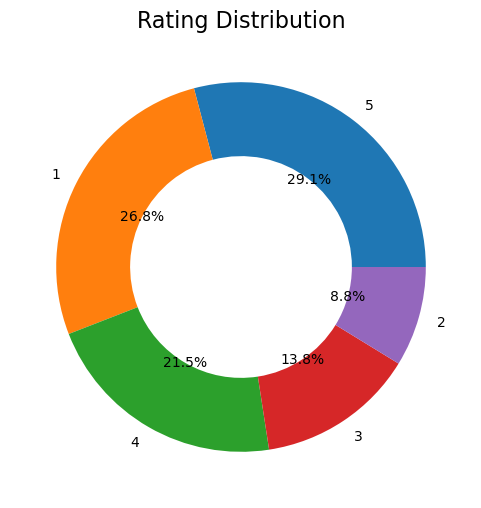

In [9]:
import matplotlib.pyplot as plt

rating_counts = data['rating'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',
        wedgeprops={'width':0.4})
plt.title("Rating Distribution", fontsize=16)
plt.show()


### Combine title and body into one text column

In [10]:
data['text'] = data['title'].astype(str) + " " + data['body'].astype(str)
data.drop(['title', 'body'], axis=1, inplace=True)
data.head()

,rating,text
0,1,Horrible product Very disappointed with the ov...
1,3,Camera quality is not like 48 megapixel Camera...
2,4,"Overall Got the mobile on the launch date,Batt..."
3,1,A big no from me 1. It doesn't work with 5.0GH...
4,1,Put your money somewhere else Not worth buying...


### Language detect

In [12]:
!pip install langdetect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     -------------------------------------- 981.5/981.5 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993250 sha256=89b1d10099958d23d2dfdc317ebdc8b910b8e7d4c1e3451d9239189a22190a48
  Stored in directory: c:\users\sabdu\appdata\local\pip\cache\wheels\eb\87\25\2dddf1c94e1786054e25022ec5530bfed52bad86d882999c48
Successfully built langdetect


  DEPRECATION: Building 'langdetect' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'langdetect'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [13]:
from langdetect import detect

data['language'] = data['text'].apply(lambda x: detect(x))
print(data['language'].value_counts())

language
en    1414
hi      11
id       5
ca       4
af       2
lv       1
ml       1
et       1
de       1
Name: count, dtype: int64


### Translate unknown language

In [15]:
!pip install deep_translator

In [16]:
from deep_translator import GoogleTranslator

# Function to translate only if not English
def translate_text(text, lang):
    try:
        if lang != 'en':  # translate only non-English reviews
            return GoogleTranslator(source='auto', target='en').translate(text)
        else:
            return text
    except:
        return text  # if translation fails, keep original

# Apply translation only where needed
data['text'] = data.apply(lambda x: translate_text(x['text'], x['language']), axis=1)

### Text cleaning function (normalization + punctuation removal)

In [17]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('[‘’“”…]', '', text)
    return text

data['clean_text'] = data['text'].apply(clean_text)
data.head()

,rating,text,language,clean_text
0,1,Horrible product Very disappointed with the ov...,en,horrible product very disappointed with the ov...
1,3,Camera quality is not like 48 megapixel Camera...,ca,camera quality is not like megapixel camera qu...
2,4,"Overall Got the mobile on the launch date,Batt...",en,overall got the mobile on the launch datebatte...
3,1,A big no from me 1. It doesn't work with 5.0GH...,en,a big no from me it doesnt work with ghz wifi ...
4,1,Put your money somewhere else Not worth buying...,en,put your money somewhere else not worth buying...


### Tokenization

In [18]:
data['tokens'] = data['clean_text'].apply(word_tokenize)
data.head()

,rating,text,language,clean_text,tokens
0,1,Horrible product Very disappointed with the ov...,en,horrible product very disappointed with the ov...,"[horrible, product, very, disappointed, with, ..."
1,3,Camera quality is not like 48 megapixel Camera...,ca,camera quality is not like megapixel camera qu...,"[camera, quality, is, not, like, megapixel, ca..."
2,4,"Overall Got the mobile on the launch date,Batt...",en,overall got the mobile on the launch datebatte...,"[overall, got, the, mobile, on, the, launch, d..."
3,1,A big no from me 1. It doesn't work with 5.0GH...,en,a big no from me it doesnt work with ghz wifi ...,"[a, big, no, from, me, it, doesnt, work, with,..."
4,1,Put your money somewhere else Not worth buying...,en,put your money somewhere else not worth buying...,"[put, your, money, somewhere, else, not, worth..."


### custom stop words

In [19]:
custom_stopwords = set([
    'aa','yr''phoneand', 'phonegood', 'phonei', 'phoneit', 'phonemain', 'phoneno', 'phoneoverall', 'phonepay', 'phonephone',
    'phonescreen', 'phonethe', 'phonevery', 'phonevery slow', 'phonedont', 'ph', 'phn', 'phon',
    'pre', 'pre installed', 'preinstalled', 'preloaded', 'okbattery', 'oke', 'okok', 'school',
    'paid', 'review', 'tube', 'dont', 'go', 'by', 'many', 'may', 'might', 'according', 'pls','plz',
    'using', 'purchased', 'purchasing', 'received', 'buy', 'bought', 'would', 'even', 'really', 'phone',
    'mobile', 'product', 'device', 'screen', 'battery', 'camera','price', 'review', 'received', 'purchased',
    'buy', 'got', 'one', 'is', 'this', 'it', 'in', 'for', 'on', 'with', 'of', 'from'
])


In [20]:
important_words = [
    'not', 'no', 'never', 'bad', 'good', 'best', 'worst', 'awful', 'terrible', 'amazing',
    'poor', 'great', 'excellent', 'happy', 'disappointed', 'unhappy', 'satisfied', 'unsatisfied',
    'recommend', 'value', 'money', 'waste', 'problem', 'issue', 'fast', 'slow', 'smooth', 'trust',
    'comfortable', 'cheap', 'expensive', 'perfect', 'camera', 'battery', 'screen', 'display',
    'sound', 'touch', 'storage', 'processor', 'ram', 'performance', 'pubg', 'gaming', 'play', 'game',
    'easy', 'difficult', 'simple', 'complicated', 'yes', 'hate', 'loved', 'liked', 'hated'
]

### Stopword removal

In [21]:
stop_words = set(stopwords.words('english'))
stop_words = stop_words - set(important_words)
all_stopwords = stop_words.union(custom_stopwords)
data['tokens'] = data['tokens'].apply(lambda x: [word for word in x if word not in all_stopwords])
data.head()

,rating,text,language,clean_text,tokens
0,1,Horrible product Very disappointed with the ov...,en,horrible product very disappointed with the ov...,"[horrible, disappointed, overall, performance,..."
1,3,Camera quality is not like 48 megapixel Camera...,ca,camera quality is not like megapixel camera qu...,"[quality, not, like, megapixel, quality, low]"
2,4,"Overall Got the mobile on the launch date,Batt...",en,overall got the mobile on the launch datebatte...,"[overall, launch, datebattery, must, appreciat..."
3,1,A big no from me 1. It doesn't work with 5.0GH...,en,a big no from me it doesnt work with ghz wifi ...,"[big, no, doesnt, work, ghz, wifi, frequency, ..."
4,1,Put your money somewhere else Not worth buying...,en,put your money somewhere else not worth buying...,"[put, money, somewhere, else, not, worth, buyi..."


### Lemmatization

In [22]:
lemmatizer = WordNetLemmatizer()
data['lemmatized'] = data['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
data.head()

,rating,text,language,clean_text,tokens,lemmatized
0,1,Horrible product Very disappointed with the ov...,en,horrible product very disappointed with the ov...,"[horrible, disappointed, overall, performance,...","[horrible, disappointed, overall, performance,..."
1,3,Camera quality is not like 48 megapixel Camera...,ca,camera quality is not like megapixel camera qu...,"[quality, not, like, megapixel, quality, low]","[quality, not, like, megapixel, quality, low]"
2,4,"Overall Got the mobile on the launch date,Batt...",en,overall got the mobile on the launch datebatte...,"[overall, launch, datebattery, must, appreciat...","[overall, launch, datebattery, must, appreciat..."
3,1,A big no from me 1. It doesn't work with 5.0GH...,en,a big no from me it doesnt work with ghz wifi ...,"[big, no, doesnt, work, ghz, wifi, frequency, ...","[big, no, doesnt, work, ghz, wifi, frequency, ..."
4,1,Put your money somewhere else Not worth buying...,en,put your money somewhere else not worth buying...,"[put, money, somewhere, else, not, worth, buyi...","[put, money, somewhere, else, not, worth, buyi..."


### Final Text column

In [23]:
data['final_text'] = data['lemmatized'].apply(lambda x: ' '.join(x))
data.head()


,rating,text,language,clean_text,tokens,lemmatized,final_text
0,1,Horrible product Very disappointed with the ov...,en,horrible product very disappointed with the ov...,"[horrible, disappointed, overall, performance,...","[horrible, disappointed, overall, performance,...",horrible disappointed overall performance samsung
1,3,Camera quality is not like 48 megapixel Camera...,ca,camera quality is not like megapixel camera qu...,"[quality, not, like, megapixel, quality, low]","[quality, not, like, megapixel, quality, low]",quality not like megapixel quality low
2,4,"Overall Got the mobile on the launch date,Batt...",en,overall got the mobile on the launch datebatte...,"[overall, launch, datebattery, must, appreciat...","[overall, launch, datebattery, must, appreciat...",overall launch datebattery must appreciatedcam...
3,1,A big no from me 1. It doesn't work with 5.0GH...,en,a big no from me it doesnt work with ghz wifi ...,"[big, no, doesnt, work, ghz, wifi, frequency, ...","[big, no, doesnt, work, ghz, wifi, frequency, ...",big no doesnt work ghz wifi frequency ghz old ...
4,1,Put your money somewhere else Not worth buying...,en,put your money somewhere else not worth buying...,"[put, money, somewhere, else, not, worth, buyi...","[put, money, somewhere, else, not, worth, buyi...",put money somewhere else not worth buyingfault...


### Text Length Analysis

Text Length Descriptive Statistics:


count    1440.000000
mean      195.440972
std       140.361053
min         4.000000
25%       115.000000
50%       162.500000
75%       231.250000
max      1653.000000
Name: text_length, dtype: float64

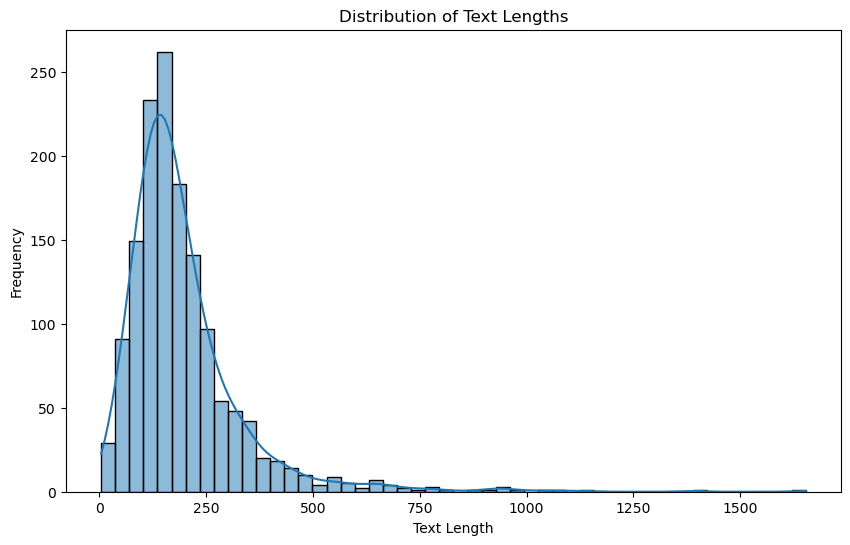

In [24]:
data['text_length'] = data['final_text'].apply(len)

print("Text Length Descriptive Statistics:")
display(data['text_length'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(data['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

### Word frequency visualization

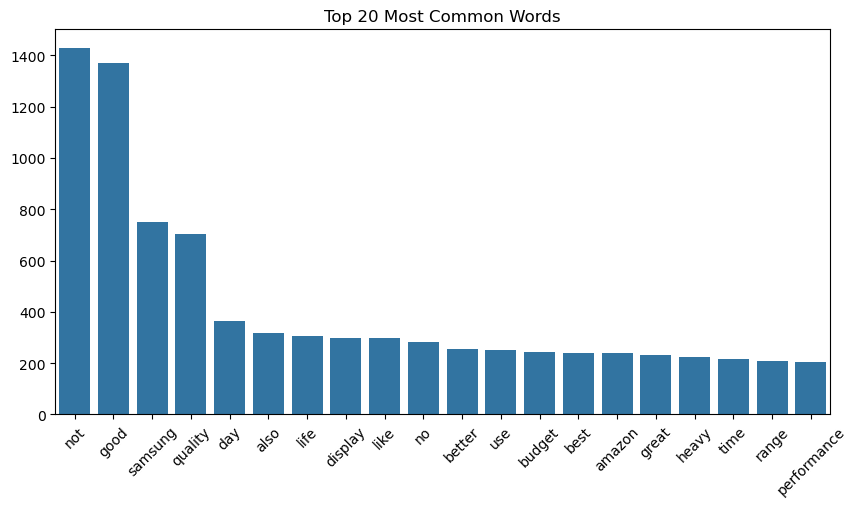

In [25]:
from collections import Counter
all_words = [word for tokens in data['lemmatized'] for word in tokens]
freq_dist = Counter(all_words)
common_words = freq_dist.most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(10,5))
sns.barplot(x=list(words), y=list(counts))
plt.title("Top 20 Most Common Words")
plt.xticks(rotation=45)
plt.show()


In [26]:
text = " ".join(data["final_text"])


### Final cleaned dataset

In [27]:
data.drop(['language', 'text', 'tokens', 'lemmatized', 'text_length'], axis=1, inplace=True)
display(data.head())
data.shape

,rating,clean_text,final_text
0,1,horrible product very disappointed with the ov...,horrible disappointed overall performance samsung
1,3,camera quality is not like megapixel camera qu...,quality not like megapixel quality low
2,4,overall got the mobile on the launch datebatte...,overall launch datebattery must appreciatedcam...
3,1,a big no from me it doesnt work with ghz wifi ...,big no doesnt work ghz wifi frequency ghz old ...
4,1,put your money somewhere else not worth buying...,put money somewhere else not worth buyingfault...


(1440, 3)

###  Generate wordcloud

In [29]:
!pip install wordcloud

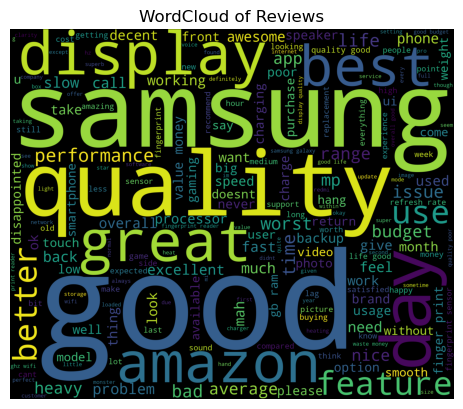

In [30]:
from wordcloud import WordCloud
wordcloud_stw = WordCloud(
                background_color= 'black',
                width = 1800,
                height = 1500,
                ).generate(text)
plt.axis('off')
plt.title("WordCloud of Reviews")
plt.imshow(wordcloud_stw)

### Sentiment Labels

In [31]:
def get_sentiment_afinn(text):
    score = text
    if score > 3:
        return "Positive"
    elif score < 3:
        return "Negative"
    else:
        return "Neutral"

In [32]:
data['Sentiment'] = data['rating'].apply(get_sentiment_afinn)
print(data[['rating', 'Sentiment']].head(10))

   rating Sentiment
0       1  Negative
1       3   Neutral
2       4  Positive
3       1  Negative
4       1  Negative
5       1  Negative
6       1  Negative
7       1  Negative
8       1  Negative
9       1  Negative


In [34]:
!pip install transformers

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   -------------------------- ------------- 6.8/10.1 MB 34.8 MB/s eta 0:00:01
   ---------------------------------------- 10.1/10.1 MB 26.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/553.2 kB ? eta -:--:--
   ------------------ --------------------- 262.1/553.2 kB ? eta -:--:--
   ---------------------------------------- 553.2/553.2 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.9 MB 3.6 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 4.0 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.9 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 6.1 MB/s eta 0:00:01
   ----------------------------

In [35]:
from transformers import pipeline

text = data['clean_text'].tolist()

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

results = classifier(text, truncation=True)

data['text_sentiment'] = [r['label'] for r in results]
print(data[['clean_text', 'text_sentiment']])


PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\sabdu\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sabdu\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


NameError: name 'torch' is not defined

### Initialize tf-idf vectorizer



In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=7000)

### Transform the Text Data



In [37]:
tfidf_vectorizer.fit(data['final_text'])
print("TF-IDF vectorizer fitted successfully.")

tfidf_matrix = tfidf_vectorizer.transform(data['final_text'])

print("Text data transformed into TF-IDF matrix.")
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF vectorizer fitted successfully.
Text data transformed into TF-IDF matrix.
TF-IDF matrix shape: (1440, 7000)


### Convert TF-IDF Matrix to DataFrame



In [38]:
# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix converted to DataFrame.")
print("TF-IDF DataFrame shape:", tfidf_df.shape)
print("\nTF-IDF DataFrame (first 5 rows):")
display(tfidf_df)

TF-IDF matrix converted to DataFrame.
TF-IDF DataFrame shape: (1440, 7000)

TF-IDF DataFrame (first 5 rows):


,able,able connect,able find,able hear,able return,absolute,absolutely,accept,acceptable,acceptable range,...,youtube facebook,youtube social,youtube social medium,youtube video,yr,zero,zoom,zoom image,zoom mp,zooming
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Confusion Matrix

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def ConfusionMatrix(y_test, y_pred, model):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Greens')
    plt.title("Confusion Matrix - Sentiment Analysis")
    plt.show()


### Grid Search(Fine Tuning)

In [40]:
from sklearn.model_selection import GridSearchCV

def train_and_tune_model(estimator, param_grid, X_train, X_test, y_train, y_test, cv=5, scoring='accuracy'):
    grid = GridSearchCV(estimator, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    print("Best cross-val score:", grid.best_score_)
    print("Test score:", grid.score(X_test, y_test))
    return grid


# 1 general prediction

### Train Test split

In [41]:
X = tfidf_df
y = data['Sentiment']

In [42]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Linear SVM

Linear SVM Accuracy: 0.7986111111111112

Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.83      0.82       102
     Neutral       0.60      0.15      0.24        40
    Positive       0.81      0.95      0.87       146

    accuracy                           0.80       288
   macro avg       0.74      0.65      0.64       288
weighted avg       0.78      0.80      0.77       288



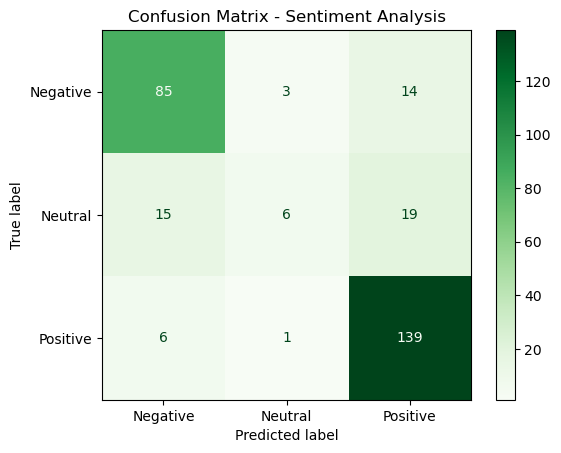

None


In [43]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print(ConfusionMatrix(y_test, y_pred_svm, svm_model))


In [44]:
svm_grid = train_and_tune_model(LinearSVC(), {'C':[0.01,0.1,1,10],'max_iter':[1000,2000]}, X_train, X_test, y_train, y_test)
print("Tuned Linear SVM Test Score:", svm_grid.score(X_test, y_test))

Best params: {'C': 1, 'max_iter': 1000}
Best cross-val score: 0.7916619612271786
Test score: 0.7986111111111112
Tuned Linear SVM Test Score: 0.7986111111111112


# 2 Binary prediction

### Train Test split

In [47]:
X = tfidf_df
y = data['text_sentiment']

KeyError: 'text_sentiment'

In [48]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Linear SVM

Linear SVM Accuracy: 0.7986111111111112

Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.83      0.82       102
     Neutral       0.60      0.15      0.24        40
    Positive       0.81      0.95      0.87       146

    accuracy                           0.80       288
   macro avg       0.74      0.65      0.64       288
weighted avg       0.78      0.80      0.77       288



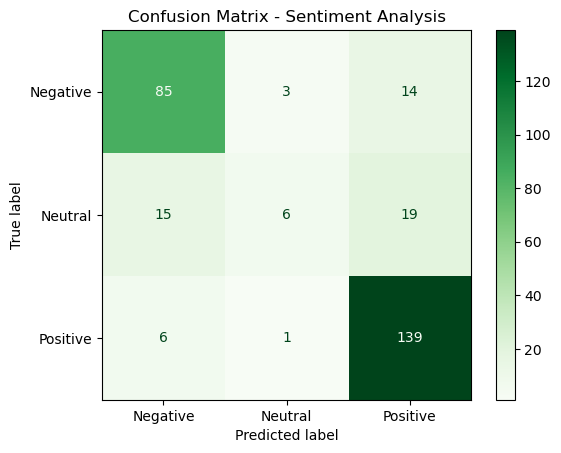

None


In [49]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print(ConfusionMatrix(y_test, y_pred_svm, svm_model))


In [50]:
svm_grid = train_and_tune_model(LinearSVC(), {'C':[0.01,0.1,1,10],'max_iter':[1000,2000]}, X_train, X_test, y_train, y_test)
print("Tuned Linear SVM Test Score:", svm_grid.score(X_test, y_test))

Best params: {'C': 1, 'max_iter': 1000}
Best cross-val score: 0.7916619612271786
Test score: 0.7986111111111112
Tuned Linear SVM Test Score: 0.7986111111111112


# 3 Removing neutral text

In [51]:
# Separate out the neutral rows using the rating_sentiment column
neutral_data = data[data['Sentiment'] == 'Neutral']
non_neutral_data = data[data['Sentiment'] != 'Neutral']

print("Neutral reviews shape:", neutral_data.shape)
print("Non-neutral reviews shape:", non_neutral_data.shape)

# Preview data
print("Neutral reviews (first 3 rows):")
display(neutral_data.head(3))
print("Non-neutral reviews (first 3 rows):")
display(non_neutral_data.head(3))


Neutral reviews shape: (199, 4)
Non-neutral reviews shape: (1241, 4)
Neutral reviews (first 3 rows):


,rating,clean_text,final_text,Sentiment
1,3,camera quality is not like megapixel camera qu...,quality not like megapixel quality low,Neutral
23,3,not so impressiveokay okaylittle over price th...,not impressiveokay okaylittle medium could not...,Neutral
30,3,good battery but average performance pros the ...,good average performance pro biggest advantage...,Neutral


Non-neutral reviews (first 3 rows):


,rating,clean_text,final_text,Sentiment
0,1,horrible product very disappointed with the ov...,horrible disappointed overall performance samsung,Negative
2,4,overall got the mobile on the launch datebatte...,overall launch datebattery must appreciatedcam...,Positive
3,1,a big no from me it doesnt work with ghz wifi ...,big no doesnt work ghz wifi frequency ghz old ...,Negative


### Transform the Text Data



In [52]:
# Fit the vectorizer on all text data first
tfidf_vectorizer.fit(data['final_text'])
print("TF-IDF vectorizer fitted successfully.")

# Transform both neutral and non-neutral data using the same fitted vectorizer
tfidf_matrix_neutral = tfidf_vectorizer.transform(neutral_data['final_text'])
tfidf_matrix_non_neutral = tfidf_vectorizer.transform(non_neutral_data['final_text'])

print("Neutral text data transformed. Shape:", tfidf_matrix_neutral.shape)
print("Non-neutral text data transformed. Shape:", tfidf_matrix_non_neutral.shape)

TF-IDF vectorizer fitted successfully.
Neutral text data transformed. Shape: (199, 7000)
Non-neutral text data transformed. Shape: (1241, 7000)


### Convert TF-IDF Matrix to DataFrame



In [53]:
tfidf_df_neutral = pd.DataFrame(tfidf_matrix_neutral.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("TF-IDF matrix (neutral) converted to DataFrame.")
print("Shape:", tfidf_df_neutral.shape)
display(tfidf_df_neutral.head())

tfidf_df_non_neutral = pd.DataFrame(tfidf_matrix_non_neutral.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("TF-IDF matrix (non-neutral) converted to DataFrame.")
print("Shape:", tfidf_df_non_neutral.shape)
display(tfidf_df_non_neutral.head())

TF-IDF matrix (neutral) converted to DataFrame.
Shape: (199, 7000)


,able,able connect,able find,able hear,able return,absolute,absolutely,accept,acceptable,acceptable range,...,youtube facebook,youtube social,youtube social medium,youtube video,yr,zero,zoom,zoom image,zoom mp,zooming
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


TF-IDF matrix (non-neutral) converted to DataFrame.
Shape: (1241, 7000)


,able,able connect,able find,able hear,able return,absolute,absolutely,accept,acceptable,acceptable range,...,youtube facebook,youtube social,youtube social medium,youtube video,yr,zero,zoom,zoom image,zoom mp,zooming
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Train Test split

In [54]:
from sklearn.model_selection import train_test_split

# Convert sparse matrices to arrays for easier handling
X_neutral_array = tfidf_matrix_neutral
X_non_neutral_array = tfidf_matrix_non_neutral

# NEUTRAL split
X_train_neutral, X_test_neutral, y_train_neutral, y_test_neutral = train_test_split(
    X_neutral_array, 
    neutral_data['Sentiment'].values,  # Convert to numpy array
    test_size=0.2, 
    random_state=42
)

print("Neutral Train shape:", X_train_neutral.shape)
print("Neutral Test shape:", X_test_neutral.shape)
print("Neutral y_train distribution:\n", pd.Series(y_train_neutral).value_counts())
print("Neutral y_test distribution:\n", pd.Series(y_test_neutral).value_counts())

# NON-NEUTRAL split
X_train_non_neutral, X_test_non_neutral, y_train_non_neutral, y_test_non_neutral = train_test_split(
    X_non_neutral_array,
    non_neutral_data['Sentiment'].values,  # Convert to numpy array
    test_size=0.2, 
    random_state=42
)

print("\nNon-neutral Train shape:", X_train_non_neutral.shape)
print("Non-neutral Test shape:", X_test_non_neutral.shape)
print("Non-neutral y_train distribution:\n", pd.Series(y_train_non_neutral).value_counts())
print("Non-neutral y_test distribution:\n", pd.Series(y_test_non_neutral).value_counts())

Neutral Train shape: (159, 7000)
Neutral Test shape: (40, 7000)
Neutral y_train distribution:
 Neutral    159
Name: count, dtype: int64
Neutral y_test distribution:
 Neutral    40
Name: count, dtype: int64

Non-neutral Train shape: (992, 7000)
Non-neutral Test shape: (249, 7000)
Non-neutral y_train distribution:
 Positive    579
Negative    413
Name: count, dtype: int64
Non-neutral y_test distribution:
 Positive    150
Negative     99
Name: count, dtype: int64


In [55]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [56]:
from sklearn.cluster import KMeans

# Set number of clusters (e.g., 2-5 for structure exploration)
n_clusters = 3

# Convert sparse matrix to dense array for clustering
X_train_neutral_dense = X_train_neutral.toarray()

# Perform clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
neutral_clusters = kmeans.fit_predict(X_train_neutral_dense)

# Get the indices of training data
train_indices = np.arange(len(neutral_data))[train_test_split(np.arange(len(neutral_data)), 
                                                             test_size=0.2, 
                                                             random_state=42)[0]]

# Create DataFrame with properly aligned data
clustered_data = pd.DataFrame({
    'cluster': neutral_clusters,
    'final_text': neutral_data['final_text'].iloc[train_indices].values
})

print("Neutral dataset clustered. Cluster counts:")
print(clustered_data['cluster'].value_counts())

# See example texts for each cluster
for clust in range(n_clusters):
    print(f"\nSample texts for cluster {clust}:")
    print(clustered_data[clustered_data['cluster'] == clust]['final_text'].head(3).tolist())

Neutral dataset clustered. Cluster counts:
cluster
2    76
1    52
0    31
Name: count, dtype: int64

Sample texts for cluster 0:
['average average life good processor little bit slow brand display good not good', 'heavy thick display ppi also low heavy person hold pocket thickness also bulky good k', 'sound quality bad not bad sound quality low loudspeaker onthis bad mobilewhen people connected whatsapp conference go mute people cant hear voice']

Sample texts for cluster 1:
['not heavycamera quality poorscreen quality poor compare othwr marketfast charging backup also oki recommend try segment like redmi mi poco', 'think choose good better phonesthe performance not upto mark doesnt look like pixelwriting pixel gb ram not experiencing level performance based spec raise doubt samsungdefinitely compare phone marking purchase decision', 'speaker new non functional speaker not functioning properlywhen call put speaker terrible humming sound no clarity sound not play audio song humming sou

C:\Users\sabdu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [57]:
# Predict cluster assignment for neutral test features
X_test_neutral_dense = X_test_neutral.toarray()
neutral_test_clusters = kmeans.predict(X_test_neutral_dense)

# Get the indices of test data
test_indices = np.arange(len(neutral_data))[train_test_split(np.arange(len(neutral_data)), 
                                                            test_size=0.2, 
                                                            random_state=42)[1]]

# Create DataFrame with properly aligned test data
test_clustered_data = pd.DataFrame({
    'cluster': neutral_test_clusters,
    'final_text': neutral_data['final_text'].iloc[test_indices].values
})

print("Cluster distribution in neutral test data:")
print(test_clustered_data['cluster'].value_counts())

# Display some test samples and their predicted clusters
for clust in range(kmeans.n_clusters):
    print(f"\nSample neutral test texts for cluster {clust}:")
    print(test_clustered_data[test_clustered_data['cluster'] == clust]['final_text'].head(3).tolist())

Cluster distribution in neutral test data:
cluster
2    31
1     6
0     3
Name: count, dtype: int64

Sample neutral test texts for cluster 0:
['average low budget average low budget not good no strong others want low budget itit range good choose others upper range', 'good storage disspoint wlan no ghz frequent network drop wanted get second thislatest o good ram internal storagedisappointing released feb didnt provide ghz wlan connectivity mistake based thought also available based release date also network signal get lost oftenthough expanded tb recommend spend additional inr k get mcouldnt return', 'average samsung providing better less average average display average charging u father mother mean use love']

Sample neutral test texts for cluster 1:
['average experience expect atleast little better first processor slow lagging quality bad mean bad think essential thing definitely need buying life fine look average quite thick model overall think okay general purpose not good', 'val

In [58]:
from sklearn.metrics import silhouette_score

# For train neutral data
score_train = silhouette_score(X_train_neutral_dense, neutral_clusters)
print("Silhouette score (train neutral clusters):", score_train)

# For test neutral data
score_test = silhouette_score(X_test_neutral_dense, neutral_test_clusters)
print("Silhouette score (test neutral clusters):", score_test)


Silhouette score (train neutral clusters): 0.0010961514429148947
Silhouette score (test neutral clusters): 0.00020138743260250826


### Linear SVM

Linear SVM Accuracy (non-neutral): 0.9397590361445783

Classification Report (non-neutral):
               precision    recall  f1-score   support

    Negative       0.90      0.95      0.93        99
    Positive       0.97      0.93      0.95       150

    accuracy                           0.94       249
   macro avg       0.93      0.94      0.94       249
weighted avg       0.94      0.94      0.94       249



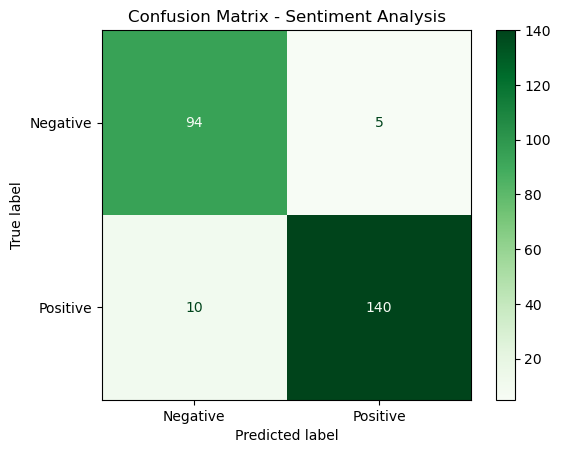

None


In [59]:
svm_model_non_neutral = LinearSVC(random_state=42)
svm_model_non_neutral.fit(X_train_non_neutral, y_train_non_neutral)
y_pred_non_neutral = svm_model_non_neutral.predict(X_test_non_neutral)

print("Linear SVM Accuracy (non-neutral):", accuracy_score(y_test_non_neutral, y_pred_non_neutral))
print("\nClassification Report (non-neutral):\n", classification_report(y_test_non_neutral, y_pred_non_neutral))
# ConfusionMatrix function as used in your notebook, if available:
print(ConfusionMatrix(y_test_non_neutral, y_pred_non_neutral, svm_model_non_neutral))


In [60]:
import joblib

# After training your LinearSVC model and TF-IDF vectorizer:
joblib.dump(svm_model_non_neutral, 'linearSVC_model.joblib')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')

['tfidf_vectorizer.joblib']

In [61]:
# Save EDA artifacts to disk for reuse (joblib)
import joblib
import os

# Directory to save EDA artifacts
os.makedirs('eda_artifacts', exist_ok=True)

saved_files = []

def try_save(var_name, obj):
    fname = os.path.join('eda_artifacts', f'eda_{var_name}.joblib')
    try:
        joblib.dump(obj, fname)
        saved_files.append(fname)
        print(f"Saved {var_name} -> {fname}")
    except Exception as e:
        print(f"Could not save {var_name}: {e}")

# Try saving the most useful EDA objects if they exist
try:
    try_save('cleaned_data', data)
except NameError:
    print('Variable `data` not found')

try:
    try_save('neutral_data', neutral_data)
except NameError:
    print('Variable `neutral_data` not found')

try:
    try_save('non_neutral_data', non_neutral_data)
except NameError:
    print('Variable `non_neutral_data` not found')

# TF-IDF DataFrames (if created)
try:
    try_save('tfidf_df_neutral', tfidf_df_neutral)
except NameError:
    print('Variable `tfidf_df_neutral` not found')

try:
    try_save('tfidf_df_non_neutral', tfidf_df_non_neutral)
except NameError:
    print('Variable `tfidf_df_non_neutral` not found')

# Frequency distribution / common words
try:
    try_save('freq_dist', freq_dist)
except NameError:
    # Try common_words tuple/list
    try:
        try_save('common_words', common_words)
    except NameError:
        print('Frequency distribution variables not found')

# WordCloud object (if generated)
try:
    try_save('wordcloud', wordcloud_stw)
except NameError:
    print('Variable `wordcloud_stw` not found')

# Save text join (if present)
try:
    try_save('text_join', text)
except NameError:
    print('Variable `text` not found')

print('\nSaved files:\n', '\n'.join(saved_files) if saved_files else 'No files were saved. Run earlier EDA cells first.')


Saved cleaned_data -> eda_artifacts\eda_cleaned_data.joblib
Saved neutral_data -> eda_artifacts\eda_neutral_data.joblib
Saved non_neutral_data -> eda_artifacts\eda_non_neutral_data.joblib
Saved tfidf_df_neutral -> eda_artifacts\eda_tfidf_df_neutral.joblib
Saved tfidf_df_non_neutral -> eda_artifacts\eda_tfidf_df_non_neutral.joblib
Saved freq_dist -> eda_artifacts\eda_freq_dist.joblib
Saved wordcloud -> eda_artifacts\eda_wordcloud.joblib
Saved text_join -> eda_artifacts\eda_text_join.joblib

Saved files:
 eda_artifacts\eda_cleaned_data.joblib
eda_artifacts\eda_neutral_data.joblib
eda_artifacts\eda_non_neutral_data.joblib
eda_artifacts\eda_tfidf_df_neutral.joblib
eda_artifacts\eda_tfidf_df_non_neutral.joblib
eda_artifacts\eda_freq_dist.joblib
eda_artifacts\eda_wordcloud.joblib
eda_artifacts\eda_text_join.joblib
